# Real Estate Data Analysis

## Import data

In [ ]:
#Required libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import copy
%matplotlib inline
import datetime as dt

In [ ]:
#convert json to csv
# json_data = pd.read_json("1612818904.9404824.txt")
# data.to_csv("data.csv", index=False, encoding='utf-8')

#read the csv data
from google.colab import files
uploaded = files.upload()
# change the type of data to Pandas Dataframe
import io
d = pd.read_csv(io.BytesIO(uploaded['idx.csv']))

Saving idx.csv to idx.csv


/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:2718: DtypeWarning: Columns (8,9,12,13,14,15,16,17,18,25,26,29,30,43,51,59,62,63,64,115,130,131,132,133,146,147,148,149,150,151,152,153,154,159,164,180,204,205,212,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,248,249,250,251,253,254,255,256,259,260,262,264,266,267,269,270,271,272,273,275,276,285,286,288,289,292,294,295,298,299,300,326,327,329,330,331,332,334,335,336,337,338,339,340,341,342,343,344,346,347,348,349,350,351,352,353,354,355) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


## Preprocessing


In [ ]:
print(d.head())
print("data size", d.shape )

                        _id  ... EasementsRestrictions4
0  602842aa4e0a0c70c80468da  ...                    NaN
1  602842aa4e0a0c70c80468db  ...                    NaN
2  602842aa4e0a0c70c80468dc  ...                    NaN
3  602842aa4e0a0c70c80468dd  ...                    NaN
4  602842aa4e0a0c70c80468de  ...                    NaN

[5 rows x 356 columns]
data size (13013, 356)


In [ ]:
print(d.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13013 entries, 0 to 13012
Columns: 356 entries, _id to EasementsRestrictions4
dtypes: float64(105), object(251)
memory usage: 35.3+ MB
None


In [ ]:
d.columns

Index(['_id', 'MLS', 'Address', 'AirConditioning', 'ApproxAge',
       'ApproxSquareFootage', 'AptUnit', 'Area', 'AreaCode', 'Balcony',
       ...
       'OtherStructures2', 'AccessToProperty2', 'WaterDeliveryFeatures1',
       'WaterFeatures4', 'LinkComment', 'EasementsRestrictions2',
       'FarmAgriculture', 'AlternativePower1', 'EasementsRestrictions3',
       'EasementsRestrictions4'],
      dtype='object', length=356)

In [ ]:
d['Style'].value_counts()

Apartment          5254
2-Storey           3603
Bungalow            929
3-Storey            644
Bungalow-Raised     239
Stacked Townhse     156
1 1/2 Storey        152
2 1/2 Storey        133
Loft                132
Multi-Level         123
Other                82
Sidesplit 4          76
Backsplit 4          67
Backsplit 3          61
Bachelor/Studio      56
Bungaloft            47
Sidesplit 3          42
Backsplit 5          35
Sidesplit 5           5
1                     2
Industrial Loft       1
Warehouse Loft        1
Name: Style, dtype: int64

In [ ]:
#filter data on column value "Sale"
dat = d[d['SaleLease']=="Sale"]
# dat = d
dat.shape

(7268, 356)

In [ ]:
#Convert object to datetime for date-time columns
# pd.to_datetime(data[["PixUpdtedDt", "IdxUpdtedDt"]])
dat["PixUpdtedDt"] = pd.to_datetime(dat["PixUpdtedDt"])
dat["IdxUpdtedDt"] = pd.to_datetime(dat["IdxUpdtedDt"])

print(dat["PixUpdtedDt"].dtype)

#'2020-10-20 12:00:35.0'
# dat['PixUpdtedDt'] =  pd.to_datetime(dat['PixUpdtedDt'], format='%Y-%b-%d %H:%M:%S')

datetime64[ns]


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


In [ ]:
#drop long text columns for now
dat_dropped = dat.drop(['Extras', 'ListBrokerage', 'Address', 'RemarksForClients', 'LegalDescription', 'ListBrokerage', 'Community','VirtualTourURL', 'TimestampSql','MLS', 
                        'CommunityCode', 'DirectionsCrossStreets', 'PostalCode' , 'SaleLease', 'Street', 'PossessionRemarks', 'StreetName', 'MunicipalityCode', 'TaxYear',
                        'Municipality', 'AreaCode', 'Area', '_id', 'LotIrregularities', 'ParcelId', 'Zoning', 'Unit', 'AptUnit', 'CondoRegistryOffice',
                        'ParkingSpot2' , 'LockerUnit', 'LockerNum', 'ParkingSpot1', "ParkingSpaces"], axis=1)

dat_dropped = dat_dropped[dat_dropped.columns.drop(list(dat_dropped.filter(regex='Desc')))]
dat_dropped.shape

(7268, 285)

## Imputing Missing Values

In [ ]:
dat_dropped['ad_type.0'].value_counts()

ResidentialProperty    4452
CondoProperty          2328
CommercialProperty      488
Name: ad_type.0, dtype: int64

In [ ]:
#filter data on column value "Sale"
dat_resid = dat_dropped[dat_dropped['ad_type.0']=="ResidentialProperty"]
# dat_resid = dat_dropped
# data = data.drop(['AptUnit'], axis=1)
dat_resid.shape

(4452, 285)

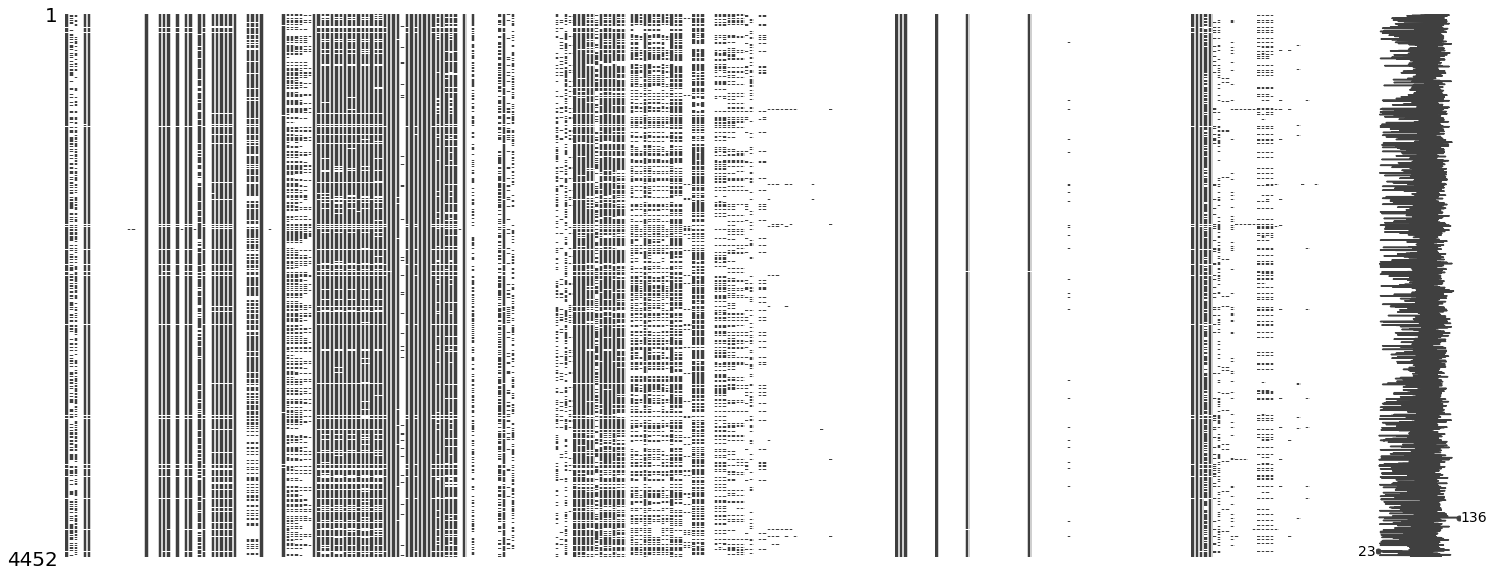

In [ ]:
#visualize missing values distributions in CondoProperty columns
import missingno as msno
msno.matrix(dat_resid)
plt.show()

In [ ]:
#Handle missing values
#drop columns with 70% NAs

# data = data.dropna()
threshold=0.3*(len(dat_resid))
print(threshold)
data = dat_resid.dropna(axis=1, thresh=threshold, how="any")
print("size of data=", data.shape)

1335.6
size of data= (4452, 108)


In [ ]:
#drop rows with 50 NAs
data=data.dropna(thresh=data.shape[1]-(len(data.columns)/2), axis=0)
data.shape

(4094, 108)

In [ ]:
#the number of NA values in each column
# print("number of NAs in columns:\n", data.isnull().sum())

# Pandas isnull.().sum() list all columns without summary
obj = data.isnull().sum()
print("number of NAs in columns:\n")
for key,value in obj.iteritems():
    print(key,",",value)

number of NAs in columns:

AirConditioning , 0
ApproxAge , 2186
ApproxSquareFootage , 1884
Basement1 , 0
Bedrooms , 0
DisplayAddressOnInternet , 0
Exterior1 , 1
FamilyRoom , 1
FireplaceStove , 0
GarageType , 0
HeatSource , 0
HeatType , 0
IdxUpdtedDt , 668
Kitchens , 0
Level1 , 62
Level2 , 60
Level3 , 63
Level4 , 65
Level5 , 79
ListPrice , 0
Map , 1206
MapColumn , 1206
MapRow , 1205
MunicipalityDistrict , 0
PixUpdtedDt , 25
PropertyFeatures1 , 1701
PropertyFeatures2 , 1837
PropertyFeatures3 , 2036
PropertyFeatures4 , 2338
PropertyFeatures5 , 2769
Province , 0
Room1 , 58
Room1Length , 392
Room1Width , 391
Room2 , 55
Room2Length , 383
Room2Width , 385
Room3 , 57
Room3Length , 389
Room3Width , 389
Room4 , 62
Room4Length , 448
Room4Width , 450
Room5 , 72
Room5Length , 466
Room5Width , 467
Rooms , 0
SpecialDesignation1 , 10
Status , 0
StreetAbbreviation , 75
Style , 0
Taxes , 0
TotalParkingSpaces , 0
TypeOwn1Out , 0
TypeOwnSrch , 0
Washrooms , 0
WashroomsType1 , 0
WashroomsType1Level , 388
W

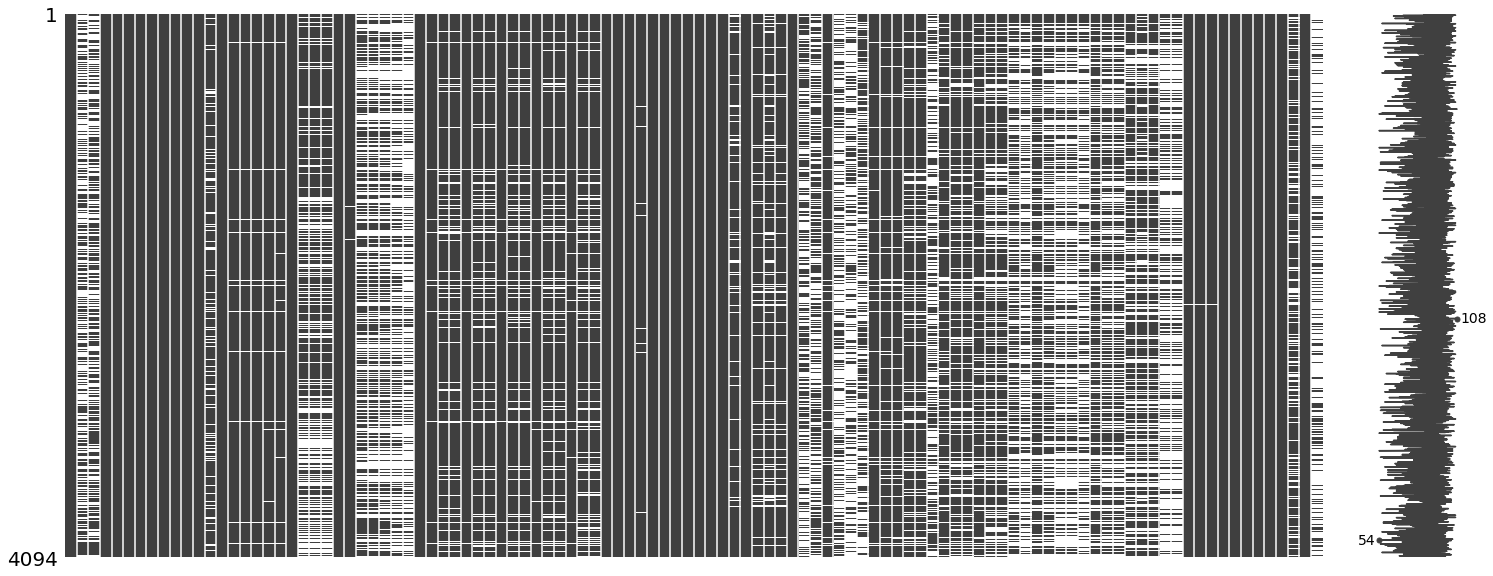

In [ ]:
#visualize missing values distributions
import missingno as msno
msno.matrix(data)
plt.show()

In [ ]:
# select the numeric columns
data_num = data.select_dtypes(include=[np.float, np.int])
print("data_num.columns\n", data_num.columns)

data_num.columns
 Index(['Bedrooms', 'Kitchens', 'ListPrice', 'Map', 'MapColumn', 'Room1Length',
       'Room1Width', 'Room2Length', 'Room2Width', 'Room3Length', 'Room3Width',
       'Room4Length', 'Room4Width', 'Room5Length', 'Room5Width', 'Rooms',
       'Taxes', 'TotalParkingSpaces', 'Washrooms', 'WashroomsType1',
       'WashroomsType1Pcs', 'WashroomsType2', 'WashroomsType2Pcs',
       'BedroomsPlus', 'RoomsPlus', 'Room6Length', 'Room6Width', 'Room7Length',
       'Room7Width', 'Room8Length', 'Room8Width', 'Room10Length',
       'Room10Width', 'Room9Length', 'Room9Width', 'WashroomsType3',
       'WashroomsType3Pcs', 'WashroomsType4', 'WashroomsType4Pcs', 'LotDepth',
       'LotFront', 'GarageSpaces'],
      dtype='object')


In [ ]:
# data_num_median=data_num[["ListPrice", "Map", "MapColumn"]]
# data_num_zero = data_num.drop(["ListPrice", "Map", "MapColumn"], axis=1)

In [ ]:

# select the date columns
data_date = data.select_dtypes(include=[np.datetime64])
print("data_date.columns\n", data_date.columns)

data_date.columns
 Index(['IdxUpdtedDt', 'PixUpdtedDt'], dtype='object')


In [ ]:
# select non-numeric columns
data_char = data.select_dtypes(exclude=[np.number, np.datetime64])

print("data_char.columns\n", data_char.columns)

data_char.columns
 Index(['AirConditioning', 'ApproxAge', 'ApproxSquareFootage', 'Basement1',
       'DisplayAddressOnInternet', 'Exterior1', 'FamilyRoom', 'FireplaceStove',
       'GarageType', 'HeatSource', 'HeatType', 'Level1', 'Level2', 'Level3',
       'Level4', 'Level5', 'MapRow', 'MunicipalityDistrict',
       'PropertyFeatures1', 'PropertyFeatures2', 'PropertyFeatures3',
       'PropertyFeatures4', 'PropertyFeatures5', 'Province', 'Room1', 'Room2',
       'Room3', 'Room4', 'Room5', 'SpecialDesignation1', 'Status',
       'StreetAbbreviation', 'Style', 'TypeOwn1Out', 'TypeOwnSrch',
       'WashroomsType1Level', 'WashroomsType2Level', 'ad_type.0',
       'LaundryLevel', 'Room6', 'Exterior2', 'CentralVac', 'Level6', 'Level7',
       'Room7', 'Basement2', 'Level8', 'Room8', 'Level10', 'Level11', 'Level9',
       'Room10', 'Room11', 'Room9', 'WashroomsType3Level', 'LotSizeCode',
       'SellerPropertyInfoStatement', 'Water', 'Sewers', 'Drive',
       'FrontingOnNSEW', 'Link', 'Pool'

In [ ]:
#replace the missing values with 0 for continuous variables and and mode for categorical variables
list_num= list(data_num)
list_char= list(data_char)
list_date= list(data_date)

data_num = data_num.fillna(0)
print("number of NAs in num data columns:\n", data_num.isnull().sum().sum())

data_char = data_char.fillna(data_char.mode().iloc[0])
print("number of NAs in char data columns:\n", data_char.isnull().sum().sum())

data_date[list_date] = data_date[list_date].fillna(data_date.mode().iloc[0])
print("number of NAs in date data columns:\n", data_date.isnull().sum().sum())


number of NAs in num data columns:
 0
number of NAs in char data columns:
 0
number of NAs in date data columns:
 0


/usr/local/lib/python3.7/dist-packages/pandas/core/frame.py:3069: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]


In [ ]:
#the frequency distribution of categories within the categorical features

for i in data_char.columns:
  print(data_char[i].value_counts())
  #the count of distinct categories within the feature
  print("count of categories=", data_char[i].value_counts().count())

Central Air    3663
None            332
Wall Unit        42
Window Unit      33
Other            24
Name: AirConditioning, dtype: int64
count of categories= 5
0-5      465
6-15     394
16-30    314
31-50    234
51-99    200
New      197
100+     104
Name: ApproxAge, dtype: int64
count of categories= 7
1500-2000    563
2000-2500    411
2500-3000    297
1100-1500    293
3500-5000    234
3000-3500    206
5000+        125
700-1100      79
< 700          2
Name: ApproxSquareFootage, dtype: int64
count of categories= 9
Finished        1964
Full             585
Apartment        358
Fin W/O          342
Unfinished       308
Part Fin         152
None             129
Crawl Space       95
Sep Entrance      74
Part Bsmt         42
W/O               18
Half              10
Walk-Up            9
Other              8
Name: Basement1, dtype: int64
count of categories= 14
Y    4078
N      16
Name: DisplayAddressOnInternet, dtype: int64
count of categories= 2
Brick             3018
Alum Siding        347

## Create Dummy variables from Categorical Features

In [ ]:
# make the categorical variable into a series of dichotomous variables
data_char = pd.get_dummies(data_char, drop_first=True)
print("data_char size", data_char.shape)

data_char size (4094, 1019)


In [ ]:
#concatenate numeric and non-numeric columns
# df = pd.concat([data_num_median, data_num_zero, data_char, data_date], axis=1)
df = pd.concat([data_num, data_char, data_date], axis=1)
print("df_shape=", df.shape)
print("df:\n", df.head()) 

df_shape= (4094, 1063)
df:
     Bedrooms  Kitchens  ...         IdxUpdtedDt         PixUpdtedDt
0        3.0       1.0  ... 2013-01-09 05:31:58 2020-10-21 22:43:36
2        7.0       1.0  ... 2019-08-08 09:56:54 2020-12-12 11:36:17
3        7.0       1.0  ... 2019-08-08 09:56:54 2020-12-12 11:43:55
6        5.0       2.0  ... 2019-08-08 09:56:54 2021-01-11 11:33:31
11       3.0       1.0  ... 2020-12-27 23:11:40 2021-01-12 13:06:30

[5 rows x 1063 columns]


In [ ]:
#number of missing values in final data (df)
df.isnull().sum().sum()

0

In [ ]:
# drop rows with ListPrice = 0  (or equivalently price with missing value)
# print(df.shape)
# df = df.drop(df[df.ListPrice == 0].index)
# print(df.shape)

In [ ]:
print(df[df.ListPrice == 0])

Empty DataFrame
Columns: [Bedrooms, Kitchens, ListPrice, Map, MapColumn, Room1Length, Room1Width, Room2Length, Room2Width, Room3Length, Room3Width, Room4Length, Room4Width, Room5Length, Room5Width, Rooms, Taxes, TotalParkingSpaces, Washrooms, WashroomsType1, WashroomsType1Pcs, WashroomsType2, WashroomsType2Pcs, BedroomsPlus, RoomsPlus, Room6Length, Room6Width, Room7Length, Room7Width, Room8Length, Room8Width, Room10Length, Room10Width, Room9Length, Room9Width, WashroomsType3, WashroomsType3Pcs, WashroomsType4, WashroomsType4Pcs, LotDepth, LotFront, GarageSpaces, AirConditioning_None, AirConditioning_Other, AirConditioning_Wall Unit, AirConditioning_Window Unit, ApproxAge_100+, ApproxAge_16-30, ApproxAge_31-50, ApproxAge_51-99, ApproxAge_6-15, ApproxAge_New, ApproxSquareFootage_1500-2000, ApproxSquareFootage_2000-2500, ApproxSquareFootage_2500-3000, ApproxSquareFootage_3000-3500, ApproxSquareFootage_3500-5000, ApproxSquareFootage_5000+, ApproxSquareFootage_700-1100, ApproxSquareFootage_

## Normalize and Scale Data

In [ ]:
for feature_name in df.columns:
    if feature_name=="ListPrice":
      price_min = df[feature_name].min()
      price_max = df[feature_name].max()
price_max

21999000.0

In [ ]:
for feature_name in df.columns:
    if feature_name=="Washrooms":
      wash_min = df[feature_name].min()
      wash_max = df[feature_name].max()
print(wash_max)
print(wash_min)

14.0
1.0


In [ ]:
#normalize data
def normalize(df):
    result = df.copy()
    for feature_name in df.columns:
      if feature_name=='IdxUpdtedDt' or  feature_name=='PixUpdtedDt':
        continue
      max_value = df[feature_name].max()
      min_value = df[feature_name].min()
      result[feature_name] = (df[feature_name] - min_value) / (max_value - min_value)
    return result

df= normalize(df)
print("df:\n", df.head())
print(df.shape)

df:
     Bedrooms  Kitchens  ...         IdxUpdtedDt         PixUpdtedDt
0       0.25  0.166667  ... 2013-01-09 05:31:58 2020-10-21 22:43:36
2       0.75  0.166667  ... 2019-08-08 09:56:54 2020-12-12 11:36:17
3       0.75  0.166667  ... 2019-08-08 09:56:54 2020-12-12 11:43:55
6       0.50  0.333333  ... 2019-08-08 09:56:54 2021-01-11 11:33:31
11      0.25  0.166667  ... 2020-12-27 23:11:40 2021-01-12 13:06:30

[5 rows x 1063 columns]
(4094, 1063)


## Detect and remove outliers

In [ ]:
from scipy import stats
import numpy as np
df_time_out=df.drop(['IdxUpdtedDt', 'PixUpdtedDt'], axis=1)
time_in= df[['IdxUpdtedDt', 'PixUpdtedDt']]
# df_time_out=df.drop(['PixUpdtedDt'], axis=1)
# time_in= df[['PixUpdtedDt']]
z = np.abs(stats.zscore(df_time_out))
print(z)

[[0.54101028 0.212197   0.18543637 ... 0.07838377 0.06828306 1.96819956]
 [3.90434062 0.212197   3.32307189 ... 0.07838377 0.06828306 0.50807856]
 [3.90434062 0.212197   3.32307189 ... 0.07838377 0.06828306 0.50807856]
 ...
 [0.57032745 0.212197   0.50694128 ... 0.07838377 0.06828306 0.50807856]
 [0.57032745 0.212197   0.50694128 ... 0.07838377 0.06828306 0.50807856]
 [0.57032745 0.212197   0.78057228 ... 0.07838377 0.06828306 0.50807856]]


In [ ]:
# threshold = 4.5
print(np.where(z > 20))


(array([   0,    1,    1, ..., 4079, 4081, 4091]), array([297, 297, 941, ..., 689, 192,  33]))


In [ ]:
# print(z[4168][34])

In [ ]:
df_o = df_time_out[(z < 40 ).all(axis=1)]
print("df_time_out size:", df_time_out.shape)
print("df_o size:",df_o.shape)
print(df_o.ListPrice[0:10])

df_time_out size: (4094, 1061)
df_o size: (3871, 1061)
0     0.066628
2     0.223712
3     0.223712
6     0.341936
11    0.062053
17    0.058715
19    0.123069
20    0.150604
22    0.086218
26    0.104484
Name: ListPrice, dtype: float64


In [ ]:
# sklearn models do not work for date type data. We need to convert it to numerical data
for column in time_in.columns:
  time_in[column]=time_in[column].map(dt.datetime.toordinal)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [ ]:
# Add 'IdxUpdtedDt', 'PixUpdtedDt' to data without outliers
print(df_o.shape, time_in.shape)
result=pd.concat([df_o,time_in], ignore_index=False, axis=1)
result=result.dropna()
print(result)
print(result.shape)

(3871, 1061) (4094, 2)
      Bedrooms  Kitchens  ListPrice  ...  Acreage_< .50  IdxUpdtedDt  PixUpdtedDt
0        0.250  0.166667   0.066628  ...            1.0       734877       737719
2        0.750  0.166667   0.223712  ...            0.0       737279       737771
3        0.750  0.166667   0.223712  ...            0.0       737279       737771
6        0.500  0.333333   0.341936  ...            0.0       737279       737801
11       0.250  0.166667   0.062053  ...            0.0       737786       737802
...        ...       ...        ...  ...            ...          ...          ...
5999     0.250  0.166667   0.022375  ...            1.0       736004       737826
6000     0.750  0.166667   0.028312  ...            0.0       735690       737827
6001     0.250  0.166667   0.016896  ...            0.0       736515       737833
6003     0.375  0.166667   0.031965  ...            0.0       736416       737823
6005     0.375  0.166667   0.018266  ...            0.0       736416       

In [ ]:
max_value_idx = result['IdxUpdtedDt'].max()
min_value_idx = result['IdxUpdtedDt'].min()
result['IdxUpdtedDt'] = (result['IdxUpdtedDt'] - min_value_idx) / (max_value_idx - min_value_idx)

# result = df.copy()
#sklearn models do not work for date type data. We need to convert it to numerical data

# time_in[column]=time_in["PixUpdtedDt"].map(dt.datetime.toordinal)

max_value_pix = result['PixUpdtedDt'].max()
min_value_pix = result['PixUpdtedDt'].min()
result['PixUpdtedDt'] = (result['PixUpdtedDt'] - min_value_pix) / (max_value_pix - min_value_pix)


In [ ]:
#export data with selected features
# from google.colab import files
# result.to_csv('result.csv', index=False) 
# files.download("result.csv")

## Train/Test Split

In [ ]:
#split data to train and test

from sklearn.model_selection import train_test_split
X= result.drop(['ListPrice'], axis=1)
Y=result.ListPrice
# X_train, X_test, y_train, y_test= train_test_split(X, Y, test_size=0.2, random_state=50)
X_train, X_test, y_train, y_test= train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
print("X_train.columns", list(X_test.columns))
print("x_train shape", X_train.shape)
print("x_test shape", X_test.shape)

X_train.columns ['Bedrooms', 'Kitchens', 'Map', 'MapColumn', 'Room1Length', 'Room1Width', 'Room2Length', 'Room2Width', 'Room3Length', 'Room3Width', 'Room4Length', 'Room4Width', 'Room5Length', 'Room5Width', 'Rooms', 'Taxes', 'TotalParkingSpaces', 'Washrooms', 'WashroomsType1', 'WashroomsType1Pcs', 'WashroomsType2', 'WashroomsType2Pcs', 'BedroomsPlus', 'RoomsPlus', 'Room6Length', 'Room6Width', 'Room7Length', 'Room7Width', 'Room8Length', 'Room8Width', 'Room10Length', 'Room10Width', 'Room9Length', 'Room9Width', 'WashroomsType3', 'WashroomsType3Pcs', 'WashroomsType4', 'WashroomsType4Pcs', 'LotDepth', 'LotFront', 'GarageSpaces', 'AirConditioning_None', 'AirConditioning_Other', 'AirConditioning_Wall Unit', 'AirConditioning_Window Unit', 'ApproxAge_100+', 'ApproxAge_16-30', 'ApproxAge_31-50', 'ApproxAge_51-99', 'ApproxAge_6-15', 'ApproxAge_New', 'ApproxSquareFootage_1500-2000', 'ApproxSquareFootage_2000-2500', 'ApproxSquareFootage_2500-3000', 'ApproxSquareFootage_3000-3500', 'ApproxSquareFoota

## Feature Selection by Random Forest

In [ ]:
# Random Forest for feature selection
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel

rf = SelectFromModel(RandomForestRegressor( random_state=10, n_estimators = 300))
rf.fit(X_train, y_train)

rf.get_support()

features= X.columns[(rf.get_support())]
print("feature importance_length: ", len(features))
print("Important features:\n", list(features))

feature importance_length:  61
Important features:
 ['Bedrooms', 'Kitchens', 'Map', 'MapColumn', 'Room1Length', 'Room1Width', 'Room2Length', 'Room2Width', 'Room3Length', 'Room3Width', 'Room4Length', 'Room4Width', 'Room5Length', 'Room5Width', 'Rooms', 'Taxes', 'TotalParkingSpaces', 'Washrooms', 'WashroomsType1Pcs', 'WashroomsType2Pcs', 'RoomsPlus', 'Room6Length', 'Room6Width', 'Room7Length', 'Room7Width', 'Room8Length', 'Room8Width', 'Room10Length', 'Room10Width', 'Room9Length', 'Room9Width', 'WashroomsType3Pcs', 'WashroomsType4', 'WashroomsType4Pcs', 'LotDepth', 'LotFront', 'GarageSpaces', 'ApproxAge_New', 'ApproxSquareFootage_3500-5000', 'ApproxSquareFootage_5000+', 'Exterior1_Concrete', 'HeatSource_Oil', 'MunicipalityDistrict_Oakville', 'MunicipalityDistrict_Oshawa', 'MunicipalityDistrict_Toronto C09', 'MunicipalityDistrict_Whitby', 'PropertyFeatures1_Level', 'PropertyFeatures2_Fenced Yard', 'PropertyFeatures5_Terraced', 'Room5_Games', 'Room5_Sunroom', 'Style_Sidesplit 4', 'Washrooms

In [ ]:
#fit random forest 
clf = RandomForestRegressor(random_state=5, n_estimators = 300)

# Train model
random_forest = clf.fit(X_train, y_train)

#feature importance scores for selected features
feat_importances = pd.DataFrame(random_forest.feature_importances_, index=X_train.columns, columns=["Importance"])
# print(feat_importances)

series=feat_importances['Importance'][feat_importances['Importance'] > 0.005]
series_sorted=series.sort_values(ascending=False) 
print(series_sorted)

Taxes                         0.613664
Washrooms                     0.074600
TotalParkingSpaces            0.022067
LotFront                      0.019458
Room5_Games                   0.018140
PropertyFeatures5_Terraced    0.014388
PixUpdtedDt                   0.012103
LotDepth                      0.010609
Rooms                         0.009661
Map                           0.007512
Name: Importance, dtype: float64


In [ ]:
print(type(series_sorted))
print(list(series_sorted.index))

<class 'pandas.core.series.Series'>
['Taxes', 'Washrooms', 'TotalParkingSpaces', 'LotFront', 'Room5_Games', 'PropertyFeatures5_Terraced', 'PixUpdtedDt', 'LotDepth', 'Rooms', 'Map']


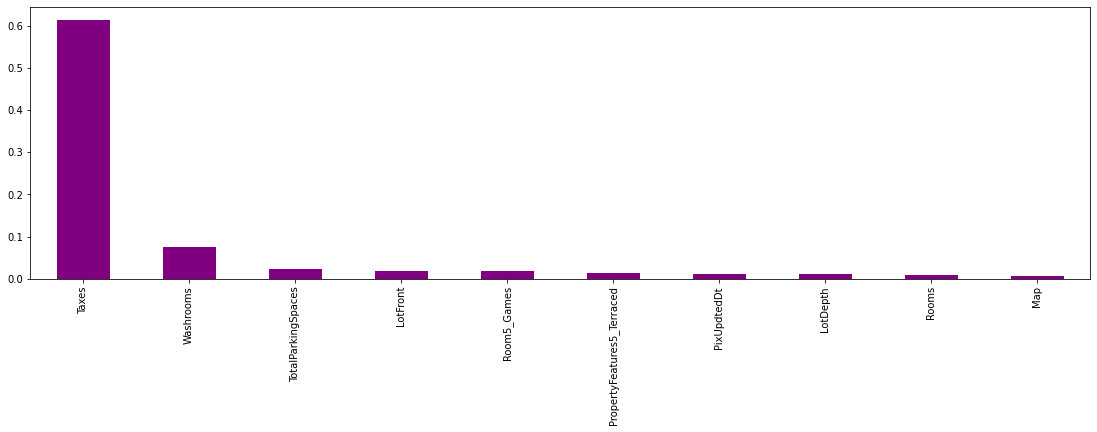

In [ ]:
#plot feature importance scores
# feat_importances.sort_values(by='Importance', ascending=False, inplace=True)
# feat_importances.plot(kind='bar', figsize=(24,5))
series_sorted.plot(kind='bar', figsize=(19,5), color= "purple")

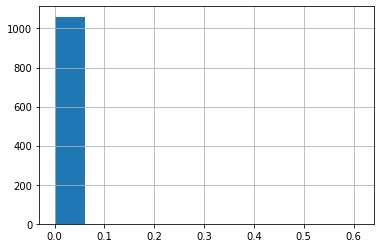

In [ ]:
pd.Series(rf.estimator_.feature_importances_.ravel()).hist()

## Feature selection using Lasso Regression

In [ ]:
#Feature selection using Lasso Regreeison
from sklearn.linear_model import LassoCV
sfm = SelectFromModel(LassoCV(), 0.25)
sfm.fit(X_train, y_train)
# print(sfm.estimator_.coef_)  # print "importance" scores
# summarize feature importance by Lasso regression
for i,v in enumerate(sfm.estimator_.coef_):
  if v>0.01:
	  print('Feature: %0d, Score: %.2f' % (i,v))

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.001371711165092493, tolerance: 0.0005345898556138666
  tol, rng, random, positive)
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0021445736919222247, tolerance: 0.0005345898556138666
  tol, rng, random, positive)
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0021569293916428034, tolerance: 0.0005345898556138666
  tol, rng, random, positive)
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:472: ConvergenceWarning: Objective did not converge. Y

Feature: 1, Score: 0.04
Feature: 14, Score: 0.02
Feature: 15, Score: 0.54
Feature: 16, Score: 0.07
Feature: 17, Score: 0.08
Feature: 36, Score: 0.01
Feature: 39, Score: 0.08
Feature: 50, Score: 0.03
Feature: 56, Score: 0.02
Feature: 76, Score: 0.05
Feature: 82, Score: 0.01
Feature: 95, Score: 0.01
Feature: 253, Score: 0.02
Feature: 288, Score: 0.02
Feature: 289, Score: 0.03
Feature: 291, Score: 0.03
Feature: 295, Score: 0.03
Feature: 296, Score: 0.04
Feature: 298, Score: 0.07
Feature: 300, Score: 0.02
Feature: 303, Score: 0.01
Feature: 320, Score: 0.01
Feature: 327, Score: 0.01
Feature: 397, Score: 0.01
Feature: 466, Score: 0.11
Feature: 597, Score: 0.09
Feature: 601, Score: 0.01
Feature: 615, Score: 0.01
Feature: 758, Score: 0.02
Feature: 1053, Score: 0.01
Feature: 1054, Score: 0.05


### Final Data with Selected Features Based on Trained Random Forest

In [ ]:
#select the data frame based on the selected features with random forest model
df_selected = result[np.intersect1d(result.columns, list(series_sorted.index))]
# df_selected = df_o[np.intersect1d(df_o.columns, features)]
# df_o_target=df_o[['ListPrice']]
df_selected = pd.concat([df_selected, Y], axis=1)
print(Y.shape, df_selected.shape) 
print(df_selected.ListPrice[0:10])
df_selected

## Export Data with Important Features

In [ ]:
#export data with selected features
from google.colab import files
# df_selected.to_csv('df_selected.csv', index=False) 
# files.download("df_selected.csv")

In [ ]:
x_data= df_selected.drop(['ListPrice'], axis=1)
y=df_selected['ListPrice']

print(x_data.shape) 
print(x_data)
print(x_data.columns)

(3871, 10)
      LotDepth  LotFront       Map  ...     Taxes  TotalParkingSpaces  Washrooms
0     0.020480  0.004918  0.127778  ...  0.058066            0.092593   0.000000
2     0.026968  0.024590  0.121111  ...  0.132075            0.074074   0.307692
3     0.026968  0.024590  0.121111  ...  0.132075            0.074074   0.307692
6     0.020253  0.023941  0.121111  ...  0.279485            0.240741   0.538462
11    0.014043  0.011710  0.115556  ...  0.049391            0.055556   0.076923
...        ...       ...       ...  ...       ...                 ...        ...
5999  0.017659  0.009623  0.000000  ...  0.024427            0.037037   0.076923
6000  0.015799  0.009368  0.000000  ...  0.050009            0.055556   0.076923
6001  0.011047  0.010948  0.000000  ...  0.024156            0.092593   0.076923
6003  0.012288  0.007023  0.494444  ...  0.035704            0.055556   0.076923
6005  0.011703  0.010539  0.000000  ...  0.032406            0.018519   0.000000

[3871 rows x 10 

# Use ML Models to Generate Predictions

## Linear Regression

In [ ]:
#Linear regression on the selected features by random forest

from sklearn.linear_model import LinearRegression
x_data= df_selected.drop(['ListPrice'], axis=1)
y=df_selected['ListPrice']

lm = LinearRegression(fit_intercept=True)
lm.fit(x_data, y)

r_sq = lm.score(x_data, y)
print('coefficient of determination:', r_sq)
print(x_data.shape) 
print(x_data)
print(x_data.columns)

coefficient of determination: 0.6960250417668151
(3871, 10)
      LotDepth  LotFront       Map  ...     Taxes  TotalParkingSpaces  Washrooms
0     0.020480  0.004918  0.127778  ...  0.058066            0.092593   0.000000
2     0.026968  0.024590  0.121111  ...  0.132075            0.074074   0.307692
3     0.026968  0.024590  0.121111  ...  0.132075            0.074074   0.307692
6     0.020253  0.023941  0.121111  ...  0.279485            0.240741   0.538462
11    0.014043  0.011710  0.115556  ...  0.049391            0.055556   0.076923
...        ...       ...       ...  ...       ...                 ...        ...
5999  0.017659  0.009623  0.000000  ...  0.024427            0.037037   0.076923
6000  0.015799  0.009368  0.000000  ...  0.050009            0.055556   0.076923
6001  0.011047  0.010948  0.000000  ...  0.024156            0.092593   0.076923
6003  0.012288  0.007023  0.494444  ...  0.035704            0.055556   0.076923
6005  0.011703  0.010539  0.000000  ...  0.032406

In [ ]:
#display adjusted R-squared for linear regression
adjusted_r_Sq= 1 - (1-r_sq)*(len(y)-1)/(len(y)-x_data.shape[1]-1)
adjusted_r_Sq

0.6952375418750193

In [ ]:
#Regression model Coefficients
print('intercept:', lm.intercept_)
print('slope:', lm.coef_)

intercept: 0.149667943299204
slope: [-0.00391246  0.14002616 -0.01143191 -0.16298861  0.16416742  0.15414259
  0.05083074  0.6569978   0.07479686  0.12266544]


In [ ]:
y_pred_lm = lm.predict(x_data)
print('predicted response:', y_pred_lm[0:10], sep='\n')
print(y_pred_lm.shape)

predicted response:
[0.06926296 0.14660107 0.14660107 0.27678647 0.04648063 0.08686091
 0.10322164 0.1446296  0.10212638 0.10439562]
(3871,)


In [ ]:
# plot the results

# x_data1= x_data['Taxes']
# plt.scatter(x_data1, y, color = "red")
# plt.plot(x_data1, y_pred_lm, color = "green")
# plt.title("House Price vs LotFront")
# plt.xlabel("LotFront")
# plt.ylabel("House Price")
# plt.show()

In [ ]:
# plot the results
# x_sub=np.arange(0,len(x_data),1)
# plt.scatter(x_sub, y, color = "black")
# plt.plot(x_sub, y_pred_lm, color = "orange")
# plt.title("")
# plt.xlabel("")
# plt.ylabel("House Price")
# plt.show()

### Split Data to Train and Test sets

In [ ]:
# split data containing important features to train and test

xtrain, xtest, ytrain, ytest= train_test_split(x_data, y, test_size=0.2, random_state=90)
# xtrain, xtest, ytrain, ytest= train_test_split(x_data, y, test_size=0.3, random_state=50)

print( xtrain.shape, ytrain.shape)
print( xtest.shape, ytest.shape)

(3096, 10) (3096,)
(775, 10) (775,)


In [ ]:
#Fit linear regression on train data and test it on test set
lm_split= lm.fit(xtrain, ytrain)

#R-squared
r_sq_split = lm_split.score(xtest, ytest)
print("R_squared", r_sq_split)
#display adjusted R-squared
adjusted_R_scuared_split=1 - (1-r_sq_split)*(len(ytest)-1)/(len(ytest)-xtest.shape[1]-1)
print("adjusted_R_scuared_split", adjusted_R_scuared_split)

R_squared 0.6021167767414592
adjusted_R_scuared_split 0.5969088811490699


In [ ]:
y_pred_lm_split = lm_split.predict(xtest)
print('predicted response:', y_pred_lm_split[0:20], sep='\n')
print(y_pred_lm_split.shape)

predicted response:
[0.0460644  0.0359502  0.07271346 0.04581517 0.07409854 0.01840897
 0.01631917 0.07885607 0.04164764 0.11628532 0.01579913 0.11190763
 0.04848181 0.04034521 0.03533292 0.03014225 0.02412261 0.06505487
 0.03591718 0.03653907]
(775,)


In [ ]:
print("\nreal prices:\n", ytest[0:20])


real prices:
 2282    0.031965
3935    0.109552
4118    0.038819
635     0.077633
3731    0.054756
3610    0.029640
5204    0.039956
1462    0.058409
955     0.030554
4813    0.060509
2871    0.018266
655     0.191245
5456    0.025115
3941    0.041056
5629    0.047947
2268    0.018266
5637    0.082195
4019    0.070784
2703    0.020499
4277    0.031924
Name: ListPrice, dtype: float64


In [ ]:
# Linear regression (cross- validated)
from sklearn.model_selection import cross_val_score
lm_cross= LinearRegression()
scores = cross_val_score(lm_cross, x_data, y, cv=10, scoring='r2')
print(scores)
print(scores.mean())
x_data

[0.55873574 0.61990099 0.68399926 0.67477382 0.76697812 0.59066812
 0.49587092 0.57074652 0.5773544  0.3257101 ]
0.5864737985710228


,LotDepth,LotFront,Map,PixUpdtedDt,PropertyFeatures5_Terraced,Room5_Games,Rooms,Taxes,TotalParkingSpaces,Washrooms
0,0.020480,0.004918,0.127778,0.783427,0.0,0.0,0.060241,0.058066,0.092593,0.000000
2,0.026968,0.024590,0.121111,0.881356,0.0,0.0,0.168675,0.132075,0.074074,0.307692
3,0.026968,0.024590,0.121111,0.881356,0.0,0.0,0.168675,0.132075,0.074074,0.307692
6,0.020253,0.023941,0.121111,0.937853,0.0,0.0,0.204819,0.279485,0.240741,0.538462
11,0.014043,0.011710,0.115556,0.939736,0.0,0.0,0.072289,0.049391,0.055556,0.076923
...,...,...,...,...,...,...,...,...,...,...
5999,0.017659,0.009623,0.000000,0.984934,0.0,0.0,0.060241,0.024427,0.037037,0.076923
6000,0.015799,0.009368,0.000000,0.986817,0.0,0.0,0.096386,0.050009,0.055556,0.076923
6001,0.011047,0.010948,0.000000,0.998117,0.0,0.0,0.072289,0.024156,0.092593,0.076923
6003,0.012288,0.007023,0.494444,0.979284,0.0,0.0,0.072289,0.035704,0.055556,0.076923


In [ ]:
from sklearn.model_selection import cross_val_predict
y_pred_lm_cross = cross_val_predict(lm_cross, x_data, y, cv=10)
y_pred_lm_cross[0:20]

array([0.06295269, 0.13614841, 0.13614841, 0.26505693, 0.04272891,
       0.08295961, 0.0954455 , 0.13548495, 0.09656907, 0.09855034,
       0.10736909, 0.04299332, 0.07504189, 0.03891857, 0.04902104,
       0.05086377, 0.04962441, 0.22424155, 0.06050524, 0.09293175])

In [ ]:
#real values of y
y[0:20]

0     0.066628
2     0.223712
3     0.223712
6     0.341936
11    0.062053
17    0.058715
19    0.123069
20    0.150604
22    0.086218
26    0.104484
27    0.118183
28    0.172980
29    0.081652
30    0.127316
31    0.067953
32    0.054756
33    0.072473
34    0.360522
37    0.081971
38    0.109552
Name: ListPrice, dtype: float64

## K Nearest Neighbors Regressor

In [ ]:
# K nearest neighbors regressor (train-test split)
from sklearn.neighbors import KNeighborsRegressor
neigh_split = KNeighborsRegressor(n_neighbors=4)
neigh_split.fit(xtrain, ytrain) 
y_pred_knn = neigh_split.predict(xtest)
print("predicted prices based on knn:\n", y_pred_knn[0:10])
print("\nreal prices:\n", ytest[0:10])
print("score: ", neigh_split.score(xtest, ytest))

predicted prices based on knn:
 [0.0434527  0.06134156 0.04856592 0.06055135 0.04790378 0.03478796
 0.03873778 0.0830649  0.04498016 0.05194505]

real prices:
 2282    0.031965
3935    0.109552
4118    0.038819
635     0.077633
3731    0.054756
3610    0.029640
5204    0.039956
1462    0.058409
955     0.030554
4813    0.060509
Name: ListPrice, dtype: float64
score:  0.5161784810818898


In [ ]:
# K nearest neighbors regressor (cross- validated)
# from sklearn.model_selection import cross_val_score
neigh_whole = KNeighborsRegressor(n_neighbors=7)
scores = cross_val_score(neigh_whole, x_data, y, cv=15, scoring='r2')
print(scores.mean())

0.6387771484386715


## Regression Tree


In [ ]:
# from sklearn.tree import DecisionTreeRegressor
# # Fit regression tree model
# # regr_tree = DecisionTreeRegressor(max_depth=4, min_samples_leaf=10, random_state=0)
# regr_tree = DecisionTreeRegressor(max_depth=4, min_samples_leaf=10)
# regr_tree.fit(xtrain, ytrain)

# # Predict
# y_pred_tree = regr_tree.predict(xtest)

# print("predicted price by tree regressor:\n", y_pred_tree[0:10])
# print("\nreal prices:\n", ytest[0:10])
# print("score: ", regr_tree.score(xtest, ytest))

## Neural Network


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from tensorflow.python.keras.models import Sequential
from tensorflow.python.keras.layers import Dense
from tensorflow.python.keras.wrappers.scikit_learn import KerasRegressor
from sklearn.metrics import r2_score

In [ ]:
#Keras Model Configuration
model_nn = Sequential()
model_nn.add(Dense(10, input_dim=len(xtrain.columns), kernel_initializer='normal', activation='relu'))
model_nn.add(Dense(8, activation='relu'))
model_nn.add(Dense(1, activation='linear'))
model_nn.summary()

model_nn.compile(loss='mse', optimizer='adam', metrics=['mse','mae'])

#fit the neural network
history = model_nn.fit(xtrain, ytrain, epochs=130, batch_size=100,  verbose=1, validation_split=0.25)

score = model_nn.evaluate(xtrain, ytrain)
print(score)

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_6 (Dense)              (None, 10)                110       
_________________________________________________________________
dense_7 (Dense)              (None, 8)                 88        
_________________________________________________________________
dense_8 (Dense)              (None, 1)                 9         
Total params: 207
Trainable params: 207
Non-trainable params: 0
_________________________________________________________________
Epoch 1/130
24/24 [==============================] - 1s 9ms/step - loss: 0.0027 - mse: 0.0027 - mae: 0.0363 - val_loss: 0.0033 - val_mse: 0.0033 - val_mae: 0.0367
Epoch 2/130
24/24 [==============================] - 0s 3ms/step - loss: 0.0017 - mse: 0.0017 - mae: 0.0271 - val_loss: 0.0029 - val_mse: 0.0029 - val_mae: 0.0279
Epoch 3/130
24/24 [==============================] - 0s 2ms/

In [ ]:
y_pred_NN = model_nn.predict(xtest)
print("y_pred_NN:\n " , y_pred_NN[0:20])

print("\nreal prices:\n", ytest[0:20])

r2=r2_score(ytest, y_pred_NN)
print("r2: ", r2)

y_pred_NN:
  [[0.04904652]
 [0.05440146]
 [0.06939991]
 [0.038604  ]
 [0.07131618]
 [0.02927071]
 [0.03611102]
 [0.07642422]
 [0.04800526]
 [0.11630792]
 [0.02689102]
 [0.11791773]
 [0.04753312]
 [0.04302463]
 [0.03979905]
 [0.0377878 ]
 [0.04387379]
 [0.06343107]
 [0.04195396]
 [0.0399323 ]]

real prices:
 2282    0.031965
3935    0.109552
4118    0.038819
635     0.077633
3731    0.054756
3610    0.029640
5204    0.039956
1462    0.058409
955     0.030554
4813    0.060509
2871    0.018266
655     0.191245
5456    0.025115
3941    0.041056
5629    0.047947
2268    0.018266
5637    0.082195
4019    0.070784
2703    0.020499
4277    0.031924
Name: ListPrice, dtype: float64
r2:  0.5974708947893527


In [ ]:
#display adjusted R-squared for Neural Network
adjusted_r_Sq= 1 - (1-r2)*(len(ytest)-1)/(len(ytest)-xtest.shape[1]-1)
adjusted_r_Sq

0.5922021892237683

dict_keys(['loss', 'mse', 'mae', 'val_loss', 'val_mse', 'val_mae'])


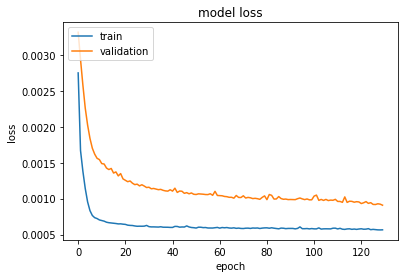

In [ ]:
print(history.history.keys())
# "Loss"
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
lm_cross= LinearRegression()
scores = cross_val_score(lm_cross, x_data, y, cv=10, scoring='r2')
print(scores.mean())

0.5864737985710228


In [ ]:
#Neural Network (cross_validation)
# model_nn = Sequential()
# model_nn.add(Dense(12, input_dim=len(xtrain.columns), kernel_initializer='normal', activation='relu'))
# model_nn.add(Dense(8, activation='relu'))
# model_nn.add(Dense(1, activation='linear'))
# model_nn.summary()

# model_nn.compile(loss='mse', optimizer='adam', metrics=['mse','mae'])

# #fit the neural network
# scores = cross_val_score(model_nn, x_data, y, epochs=140, batch_size=100,  verbose=1, cv=10, scoring='r2')
# print(scores.mean())
# history = model_nn.fit(xtrain, ytrain, epochs=140, batch_size=100,  verbose=1, validation_split=0.25)

# score = model_nn.evaluate(xtrain, ytrain)
# print(score)

In [ ]:
ytest_realscale= ytest.copy()
for i in range(len(ytest_realscale)):
  ytest_realscale.iloc[i]=(ytest_realscale.iloc[i]*(price_max-price_min))+price_min
  ytest_realscale.iloc[i]= int(ytest_realscale.iloc[i])
print("real prices:\n", ytest_realscale[0:20])
# print(xtest.iloc[[15], [0, 1, 2, 3]])

real prices:
 2282     799900.0
3935    2499000.0
4118     950000.0
635     1800000.0
3731    1299000.0
3610     749000.0
5204     974900.0
1462    1379000.0
955      769000.0
4813    1425000.0
2871     499900.0
655     4288000.0
5456     649900.0
3941     999000.0
5629    1149900.0
2268     499900.0
5637    1899899.0
4019    1649999.0
2703     548800.0
4277     799000.0
Name: ListPrice, dtype: float64


In [ ]:
# change predicted price to normal scale 
for i in range(len(y_pred_NN)):
  y_pred_NN[i]=((y_pred_NN[i]*(price_max-price_min))+price_min).astype(int)

print("predicted price based on NN=\n",y_pred_NN[0:20])

predicted price based on NN=
 [[1173974.]
 [1291243.]
 [1619695.]
 [ 945292.]
 [1661660.]
 [ 740902.]
 [ 890698.]
 [1773521.]
 [1151172.]
 [2646938.]
 [ 688789.]
 [2682192.]
 [1140832.]
 [1042100.]
 [ 971463.]
 [ 927418.]
 [1060696.]
 [1488983.]
 [1018653.]
 [ 974381.]]


In [ ]:
y_pred_NN=pd.DataFrame(y_pred_NN)
ytest_realscale=pd.DataFrame(ytest_realscale)
# y_pred_NN["y"]= ytest_realscale
# new = pd.concat([y_pred_NN, ytest_realscale], axis=1)
print(ytest_realscale.shape)
print(y_pred_NN.shape)

(775, 1)
(775, 1)


In [ ]:
y_pred_NN

,0
0,1173974.0
1,1291243.0
2,1619695.0
3,945292.0
4,1661660.0
...,...
770,5681797.0
771,1109475.0
772,3392522.0
773,751368.0


In [ ]:
y_pred_NN
y_pred_NN.head()

,0
0,1173974.0
1,1291243.0
2,1619695.0
3,945292.0
4,1661660.0


In [ ]:
ytest_realscale.isnull().sum()

ListPrice    0
dtype: int64

In [ ]:
y_pred_NN.isnull().sum()

0    0
dtype: int64